# Checking $E_1 - E_0$ on multiple lattice sizes

In [ ]:
import os
import sys
import logging
import math
from pathlib import Path
import subprocess
import numpy as np
import h5py
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax.sharding import NamedSharding, PartitionSpec, AxisType
from jax.experimental.sparse.linalg import lobpcg_standard
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.ground_locg import ground_locg
from skqd_z2lgt.sqd import get_hamiltonian_arrays, sqd
from skqd_z2lgt.ising_dmrg import ising_dmrg
sys.path.append('/home/iiyama/src/skqd_z2lgt/lib')
from ising_hamiltonian import make_apply_h

visible_devices = '4,5,6,7'
os.environ['CUDA_VISIBLE_DEVICES'] = visible_devices
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.1'
jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO)

python = '/home/iiyama/src/qii-miyabi-kawasaki/.venv/bin/python'
data_dir = Path('/data/iiyama/2dz2/buildup')

In [ ]:
data_dir = Path('/data/iiyama/2dz2/buildup/excited_states')
script = '/home/iiyama/src/skqd_z2lgt/scripts/compute_excited_state.py'
gaps = {}
for nrow in range(2, 10, 2):
    for ncol in range(2, 9):
        nplaq = nrow * ncol
        if nplaq > 28:
            continue
        path = str(data_dir / f'{nrow}_{ncol}.h5')
        print(nrow, ncol)
        if not os.path.exists(path):
            # (4, 7), (6, 4), (8, 3) were executed on iutgpu05 separately
            subprocess.run([python, script, f'{nrow}', f'{ncol}'])
        with h5py.File(path, 'r', libver='latest') as source:
            eigvals = source['eigvals'][()]
        gaps[(nrow, ncol)] = eigvals[1] - eigvals[0]

2 2
2 3
2 4
2 5
2 6
2 7
2 8
4 2
4 3
4 4
4 5
4 6
4 7
6 2
6 3
6 4
8 2
8 3


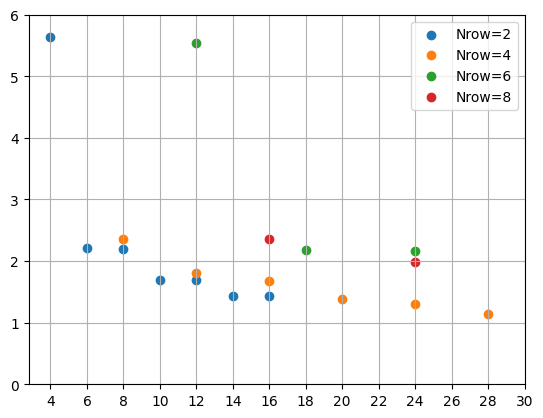

In [ ]:
plt.scatter([np.prod(key) for key in gaps.keys() if key[0] == 2], list(value for key, value in gaps.items() if key[0] == 2), label='Nrow=2')
plt.scatter([np.prod(key) for key in gaps.keys() if key[0] == 4], list(value for key, value in gaps.items() if key[0] == 4), label='Nrow=4')
plt.scatter([np.prod(key) for key in gaps.keys() if key[0] == 6], list(value for key, value in gaps.items() if key[0] == 6), label='Nrow=6')
plt.scatter([np.prod(key) for key in gaps.keys() if key[0] == 8], list(value for key, value in gaps.items() if key[0] == 8), label='Nrow=8')
plt.ylim(0., 6.)
ticks = np.arange(4, 32, 2)
plt.xticks(ticks, [f'{x}' for x in ticks])
plt.grid()
plt.legend();

The system appears to be gapped. For nrow=8, we expect the gap to be >~ 2.